# **1. Perkenalan Dataset**


Dataset ini berisi informasi mengenai 10.000 karyawan yang digunakan untuk menganalisis dan memprediksi kemungkinan seorang karyawan meninggalkan perusahaan (employee attrition). Dataset mencakup berbagai faktor seperti data demografis, kondisi pekerjaan, performa kerja, hingga kepuasan lingkungan kerja.

> Variabel target pada dataset ini adalah **Attrition**, yang menunjukkan apakah seorang karyawan keluar dari perusahaan *(Yes)* atau tetap bekerja *(No)*.

Dataset ini sangat cocok digunakan untuk:
1. Pemodelan klasifikasi (classification)
2. Analisis sumber daya manusia (Human Resource Analytics)
3. Prediksi turnover karyawan
4. Studi kepuasan dan performa kerja
5. Implementasi pipeline machine learning dan MLOps

Kolom pada dataset:
1. Employee_ID : ID unik setiap karyawan
2. Age : Usia karyawan
3. Gender : Jenis kelamin karyawan
4. Marital_Status : Status pernikahan
5. Department : Departemen tempat bekerja
6. Job_Role : Posisi pekerjaan
7. Job_Level : Level jabatan dalam perusahaan
8. Monthly_Income : Pendapatan bulanan
9. Hourly_Rate : Pendapatan per jam
10. Years_at_Company : Lama bekerja di perusahaan
11. Years_in_Current_Role : Lama bekerja pada posisi saat ini
12. Years_Since_Last_Promotion : Lama sejak promosi terakhir
13. Work_Life_Balance : Penilaian keseimbangan kerja dan kehidupan
14. Job_Satisfaction : Tingkat kepuasan kerja
15. Performance_Rating : Penilaian performa kerja
16. Training_Hours_Last_Year : Jumlah jam pelatihan tahun lalu
17. Overtime : Status lembur
18. Project_Count : Jumlah proyek yang dikerjakan
19. Average_Hours_Worked_Per_Week : Rata-rata jam kerja per minggu
20. Absenteeism : Jumlah ketidakhadiran
21. Work_Environment_Satisfaction : Kepuasan lingkungan kerja
22. Relationship_with_Manager : Hubungan dengan atasan
23. Job_Involvement : Tingkat keterlibatan kerja
24. Distance_From_Home : Jarak rumah ke kantor
25. Number_of_Companies_Worked : Jumlah perusahaan yang pernah ditempati
26. Attrition : Status keluar/tidaknya karyawan dari perusahaan

Sumber dataset (Kaggle): https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset

# **2. Import Library**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

In [6]:
# Load dataset
data = pd.read_csv("../Employee-Attrition-Dataset_raw/employee_attrition.csv")

In [10]:
data.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [11]:
data.tail()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
995,996,27,Female,Divorced,HR,Analyst,2,4172,76,24,...,No,4,46,10,3,1,4,24,4,No
996,997,47,Male,Single,IT,Manager,4,11007,71,19,...,Yes,7,36,16,3,2,4,39,3,Yes
997,998,50,Female,Divorced,IT,Executive,1,4641,43,25,...,Yes,1,46,9,2,3,3,33,2,No
998,999,28,Female,Married,HR,Executive,4,19855,92,13,...,No,4,52,17,4,1,4,41,4,No
999,1000,48,Female,Divorced,IT,Analyst,2,11738,39,1,...,Yes,2,59,5,1,4,3,43,2,No


In [7]:
# Melihat ukuran dataset
data.shape

(1000, 26)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

# **4. Exploratory Data Analysis (EDA)**

## 1. Mengecek missing values

In [9]:
print(data.isnull().sum())

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64


## 2. Mengecek data duplikat

In [10]:
print(data.duplicated().sum())

0


## 3. Menampilkan distribusi data kategorikal

In [11]:
for col in data.select_dtypes(include=['object']).columns:
    print(f"\nKolom: {col}")
    print(data[col].value_counts())


Kolom: Gender
Gender
Male      516
Female    484
Name: count, dtype: int64

Kolom: Marital_Status
Marital_Status
Married     348
Single      339
Divorced    313
Name: count, dtype: int64

Kolom: Department
Department
Finance      218
HR           211
Sales        199
Marketing    198
IT           174
Name: count, dtype: int64

Kolom: Job_Role
Job_Role
Manager      268
Executive    252
Analyst      251
Assistant    229
Name: count, dtype: int64

Kolom: Overtime
Overtime
No     512
Yes    488
Name: count, dtype: int64

Kolom: Attrition
Attrition
No     811
Yes    189
Name: count, dtype: int64


## 4. Visualisasi distribusi target attrition

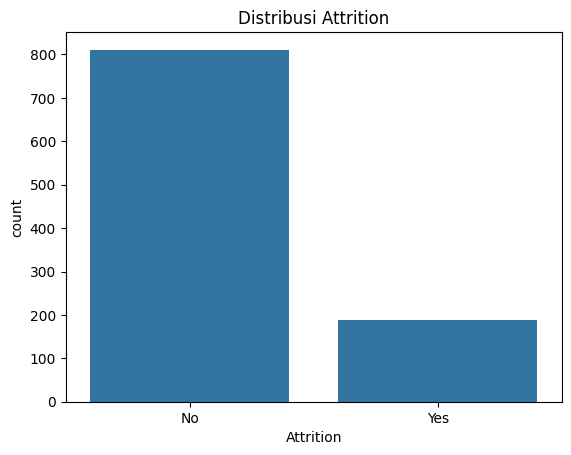

In [12]:
sns.countplot(x='Attrition', data=data)
plt.title("Distribusi Attrition")
plt.show()

## 5. Visualisasi korelasi fitur numerik

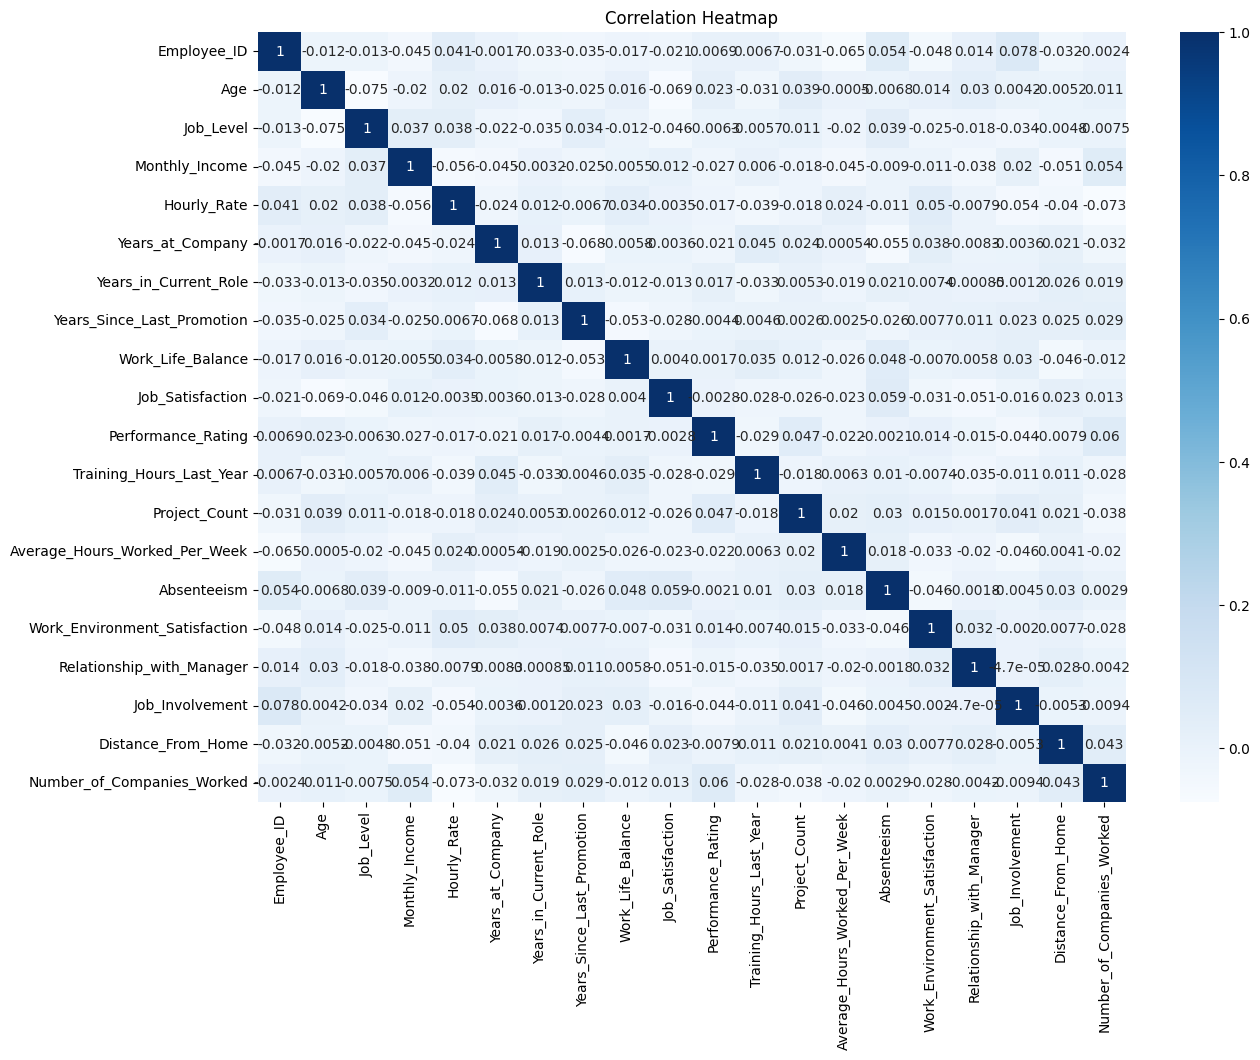

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
print("\nRata-rata Pendapatan Berdasarkan Attrition")
print(data.groupby("Attrition")["Monthly_Income"].mean())


Rata-rata Pendapatan Berdasarkan Attrition
Attrition
No     11471.595561
Yes    11621.349206
Name: Monthly_Income, dtype: float64


In [15]:
print("\nJumlah Attrition Berdasarkan Overtime")
print(data.groupby("Overtime")["Attrition"].value_counts())


Jumlah Attrition Berdasarkan Overtime
Overtime  Attrition
No        No           412
          Yes          100
Yes       No           399
          Yes           89
Name: count, dtype: int64


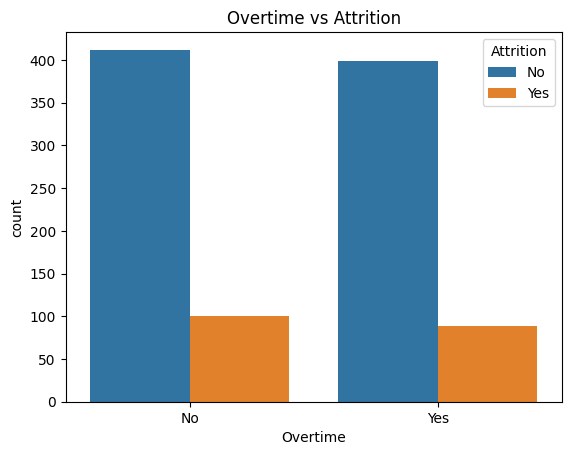

In [16]:
# Visualisasi overtime terhadap attrition
sns.countplot(x='Overtime', hue='Attrition', data=data)
plt.title("Overtime vs Attrition")
plt.show()

Insight awal yang diperoleh:

- Karyawan yang sering melakukan overtime cenderung memiliki tingkat attrition lebih tinggi.
- Karyawan dengan job satisfaction rendah lebih banyak melakukan resign.
- Pendapatan bulanan yang lebih rendah cenderung berkaitan dengan attrition yang lebih tinggi.

# **5. Data Preprocessing**

In [17]:
# Membuat salinan dataframe
df = data.copy()

## 1. Menghapus Kolom yang Tidak Diperlukan

In [18]:
df = df.drop(columns=['Employee_ID'])

## 2. Menangani Missing Values

In [19]:
df = df.dropna()

## 3. Menghapus Data Duplikat

In [20]:
df = df.drop_duplicates()

## 4. Encoding Data Kategorikal

In [21]:
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

## 5. Standarisasi Fitur

In [22]:
numerical_cols = df.select_dtypes(include=['number']).columns

target_col = 'Attrition'

numerical_cols = numerical_cols.drop(target_col)

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

## 6. Deteksi dan Penanganan Outlier

In [23]:
for feature in numerical_cols:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[
        (df[feature] >= lower_bound) &
        (df[feature] <= upper_bound)
    ]

## 7. Menyimpan Dataset Hasil Preprocessing

In [24]:
import os

os.makedirs(
    "Employee-Attrition-Dataset_preprocessing",
    exist_ok=True
)

df.to_csv(
    "Employee-Attrition-Dataset_preprocessing/employee_attrition_processed.csv",
    index=False
)